# UAV Battery Tool — Notebook 01: Battery Selection Tool

Filter the battery catalogue by mission requirements and add selected packs to
the configurator for analysis.

**Workflow:**
1. Set filter criteria (series rating, capacity, current, chemistry, weight)
2. Review the filtered and ranked list
3. Select batteries to carry forward
4. Save selection to `analysis_config.json` for use in 01_configurator and all analysis notebooks

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from batteries.database import BatteryDatabase

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.25})

DB_PATH = '../battery_db.xlsx'
db = BatteryDatabase(DB_PATH) if os.path.exists(DB_PATH) else BatteryDatabase()
db.load()

print(f'Catalogue loaded: {len(db.packs)} battery packs')
print(f'Chemistries available: {sorted(set(p.chemistry_id for p in db.packs.values()))}')
print()
print('All packs:')
for pid, p in db.packs.items():
    print(f'  {pid:<30} {p.chemistry_id:<10} {p.cells_series}S{p.cells_parallel}P  '
          f'{p.pack_capacity_ah*1000:.0f} mAh  {p.max_cont_discharge_a:.0f} A  '
          f'{p.pack_weight_g:.0f} g')

Catalogue loaded: 125 battery packs
Chemistries available: ['LIFEPO4', 'LIHV', 'LION21', 'LIPO', 'SSS']

All packs:
  BAT_FPV_4S1P                   LIPO       4S1P  1300 mAh  65 A  128 g
  BAT_MICRO_1S                   LIHV       1S1P  550 mAh  5 A  14 g
  BAT_MID_6S2P                   LION21     6S2P  9000 mAh  90 A  840 g
  BAT_MID_6S4P                   LION21     6S4P  20000 mAh  56 A  1692 g
  BAT_AG_6S1P                    LIFEPO4    6S1P  10000 mAh  30 A  1860 g
  BAT_HLIFT_6S2P                 LIFEPO4    6S2P  5000 mAh  140 A  912 g
  BAT_LE_12S2P                   LION21     12S2P  8000 mAh  70 A  1656 g
  BAT_SSS_6S1P                   SSS        6S1P  5000 mAh  12 A  606 g
  TATTU_TATTU_ULTRA_HIGH_VOLTAGE_41000MAH_5C_23_7V_6 LIPO       6S7P  41000 mAh  205 A  3790 g
  TATTU_TATTU_SEMI_SOLID_STATE_350WH_KG_33000MAH_10C LIPO       14S1P  33000 mAh  330 A  5486 g
  TATTU_TATTU_SEMI_SOLID_STATE_330WH_KG_33000MAH_10C LIPO       14S1P  33000 mAh  330 A  5701 g
  TATTU_TATTU_SEM

## 1 · Set Filter Criteria

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# FILTER CRITERIA  —  set None to skip a filter
# ═══════════════════════════════════════════════════════════════════════════════

CELLS_SERIES      = 12    # e.g. 6  — exact series cell count (None = any)
MIN_CAPACITY_MAH  = 4000    # minimum pack capacity in mAh (None = any)
MIN_CONT_CURRENT  = 20.0    # minimum max continuous discharge current in A (None = any)
CHEMISTRY         = None    # e.g. 'LIPO', 'LION21', 'LIFEPO4' (None = any)
MAX_WEIGHT_G      = 4000    # maximum pack weight in grams (None = any)

# ───────────────────────────────────────────────────────────────────────────────
print('Active filters:')
print(f'  Cells series     : {CELLS_SERIES   if CELLS_SERIES   is not None else "any"}')
print(f'  Min capacity     : {MIN_CAPACITY_MAH if MIN_CAPACITY_MAH is not None else "any"} mAh')
print(f'  Min cont current : {MIN_CONT_CURRENT if MIN_CONT_CURRENT is not None else "any"} A')
print(f'  Chemistry        : {CHEMISTRY      if CHEMISTRY      is not None else "any"}')
print(f'  Max weight       : {MAX_WEIGHT_G   if MAX_WEIGHT_G   is not None else "any"} g')

Active filters:
  Cells series     : 12
  Min capacity     : 4000 mAh
  Min cont current : 20.0 A
  Chemistry        : any
  Max weight       : 4000 g


## 2 · Filtered & Ranked Results

In [8]:
def filter_packs(packs_dict,
                 cells_series=None,
                 min_capacity_mah=None,
                 min_cont_current=None,
                 chemistry=None,
                 max_weight_g=None):
    """
    Return a filtered, weight-sorted DataFrame of BatteryPack entries.

    Parameters
    ----------
    cells_series      : int   — exact series cell count
    min_capacity_mah  : float — minimum pack capacity [mAh]
    min_cont_current  : float — minimum max continuous discharge current [A]
    chemistry         : str   — chemistry ID (case-insensitive)
    max_weight_g      : float — maximum pack weight [g]
    """
    rows = []
    for pid, p in packs_dict.items():
        # ── Apply each filter ────────────────────────────────────────────────
        if cells_series is not None and p.cells_series != int(cells_series):
            continue
        if min_capacity_mah is not None and p.pack_capacity_ah * 1000 < min_capacity_mah:
            continue
        if min_cont_current is not None and p.max_cont_discharge_a < min_cont_current:
            continue
        if chemistry is not None and p.chemistry_id.upper() != chemistry.upper():
            continue
        if max_weight_g is not None and p.pack_weight_g > max_weight_g:
            continue

        rows.append({
            'ID':              pid,
            'Name':            p.name,
            'Chemistry':       p.chemistry_id,
            'Config':          f'{p.cells_series}S{p.cells_parallel}P',
            'Capacity (mAh)':  int(p.pack_capacity_ah * 1000),
            'Voltage (V)':     p.pack_voltage_nom,
            'Energy (Wh)':     p.pack_energy_wh,
            'Max I cont (A)':  p.max_cont_discharge_a,
            'Max P cont (W)':  p.max_cont_discharge_w,
            'IR (mΩ)':       p.internal_resistance_mohm,
            'Weight (g)':      p.pack_weight_g,
            'Sp. Energy (Wh/kg)': p.specific_energy_wh_kg,
            'Cycles':          p.cycle_life,
            'UAV class':       p.uav_class or '—',
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values('Weight (g)').reset_index(drop=True)


df_filtered = filter_packs(
    db.packs,
    cells_series=CELLS_SERIES,
    min_capacity_mah=MIN_CAPACITY_MAH,
    min_cont_current=MIN_CONT_CURRENT,
    chemistry=CHEMISTRY,
    max_weight_g=MAX_WEIGHT_G,
)

print(f'{len(df_filtered)} pack(s) match the criteria:')
print()
if df_filtered.empty:
    print('  No packs match. Try relaxing the filters.')
else:
    display_cols = ['ID','Chemistry','Config','Capacity (mAh)','Voltage (V)',
                    'Energy (Wh)','Max I cont (A)','IR (mΩ)','Weight (g)',
                    'Sp. Energy (Wh/kg)','Cycles']
    print(df_filtered[display_cols].to_string(index=True))
    print()
    print(f'Lightest : {df_filtered.iloc[0]["ID"]}  ({df_filtered.iloc[0]["Weight (g)"]:.0f} g)')
    print(f'Highest energy: {df_filtered.loc[df_filtered["Energy (Wh)"].idxmax(), "ID"]}  '
          f'({df_filtered["Energy (Wh)"].max():.0f} Wh)')

6 pack(s) match the criteria:

                                                   ID Chemistry Config  Capacity (mAh)  Voltage (V)  Energy (Wh)  Max I cont (A)  IR (mΩ)  Weight (g)  Sp. Energy (Wh/kg)  Cycles
0                                        BAT_LE_12S2P    LION21  12S2P            8000         43.8        350.0            70.0     36.0      1656.0               212.0     500
1                 GREPOW_TATTU_12S_LIPO_DRONE_BATTERY      LIPO  12S1P           10000         44.4        444.0           100.0     12.0      2800.0               158.6     400
2    GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY      LIPO  12S1P           10000         44.4        444.0           300.0     12.0      2800.0               158.6     400
3  TATTU_TATTU_PLUS_1_0_COMPACT_VERSION_10000MAH_44_4      LIPO  12S1P           10000         44.4        444.0           150.0     12.0      2978.0               149.1     300
4  GREPOW_TATTU_PLUS_1_0_12S_10000MAH_44_4V_15C_LIPO_      LIPO  12S1P         

## 3 · Visual Comparison

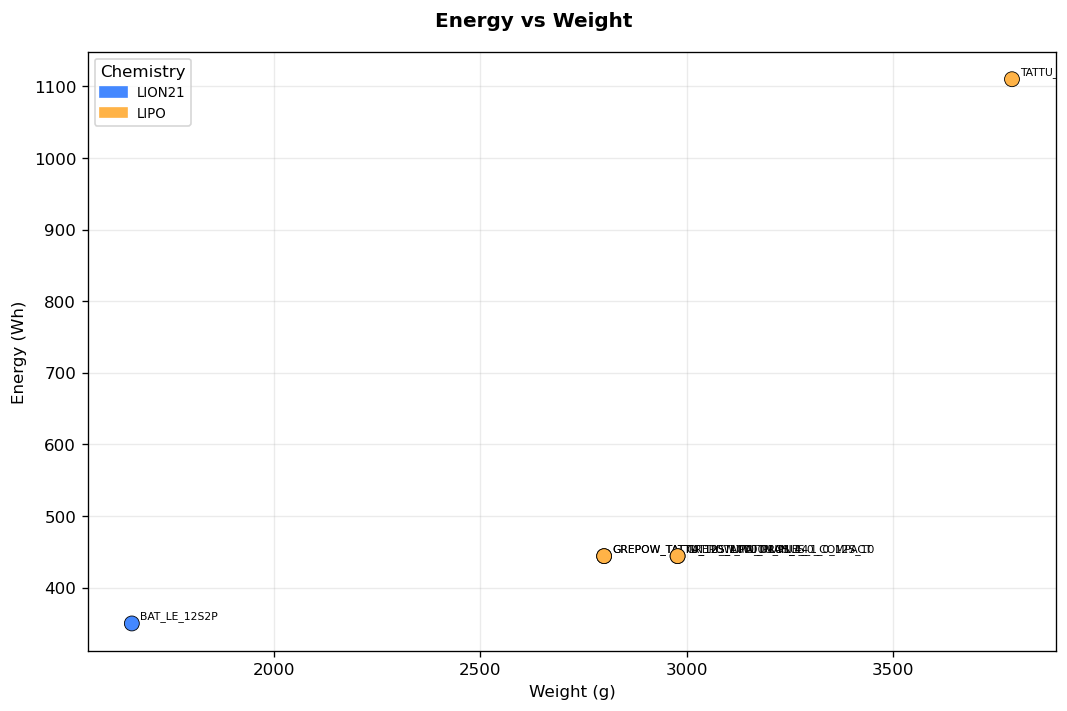

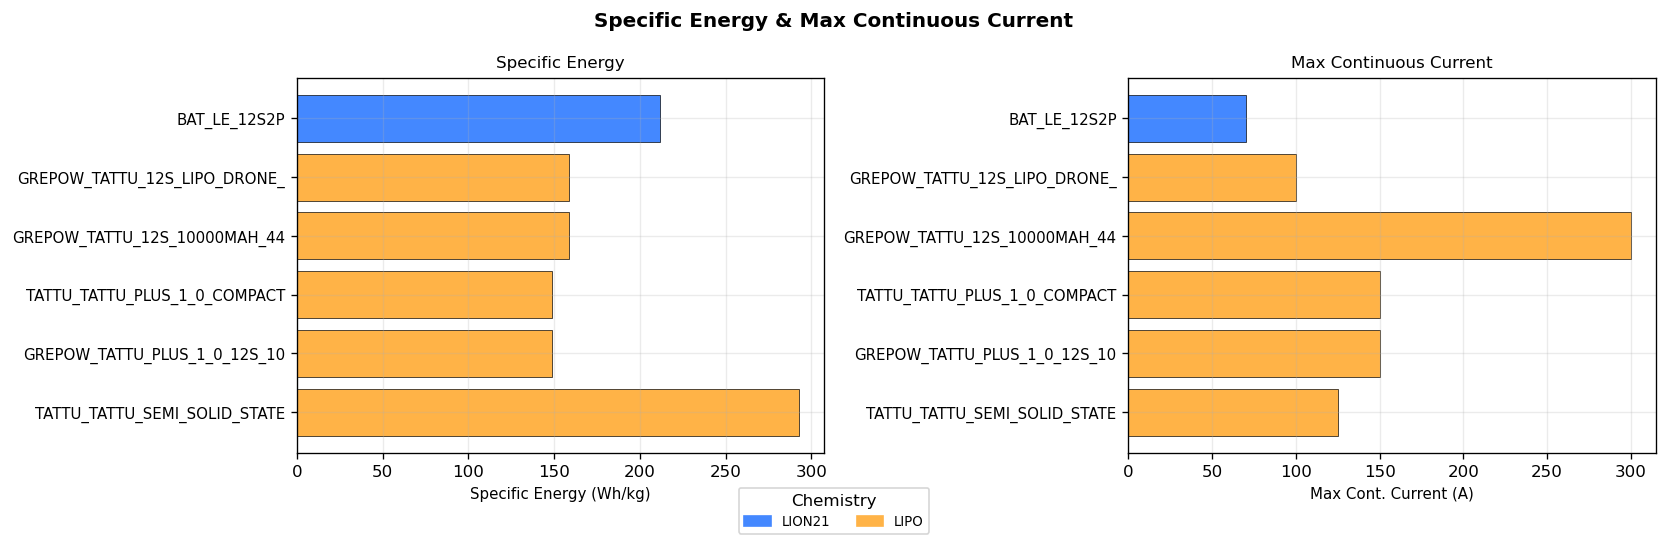

In [9]:
CHEM_COLORS = {
    'LIPO':    '#FFB347',
    'LION21':  '#4488FF',
    'LION':    '#82B4FF',
    'LIFEPO4': '#66BB6A',
    'SSS':     '#AB47BC',
    'LITO':    '#26C6DA',
    'SOLID':   '#FF7043',
    'NIMH':    '#90A4AE',
}

if df_filtered.empty:
    print('No results to plot.')
else:
    n = len(df_filtered)

    # ── Shorten IDs for axis labels ───────────────────────────────────────────
    MAX_LABEL = 28
    df_plot = df_filtered.copy()
    df_plot['_label'] = df_plot['ID'].str[:MAX_LABEL]
    # De-duplicate truncated labels by appending a counter where needed
    seen = {}
    labels = []
    for lbl in df_plot['_label']:
        if lbl in seen:
            seen[lbl] += 1
            labels.append(f'{lbl[:MAX_LABEL-2]}~{seen[lbl]}')
        else:
            seen[lbl] = 0
            labels.append(lbl)
    df_plot['_label'] = labels

    colors = [CHEM_COLORS.get(c, '#888') for c in df_plot['Chemistry']]

    # ── Figure 1: scatter  Energy vs Weight ──────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(9, 6))
    fig1.suptitle('Energy vs Weight', fontsize=12, fontweight='bold')

    ax1.scatter(df_plot['Weight (g)'], df_plot['Energy (Wh)'],
                c=colors, s=80, edgecolors='black', linewidths=0.5, zorder=4)

    # Only annotate when the number of points is manageable
    if n <= 25:
        for _, row in df_plot.iterrows():
            ax1.annotate(row['_label'],
                         (row['Weight (g)'], row['Energy (Wh)']),
                         textcoords='offset points', xytext=(5, 3), fontsize=6.5,
                         clip_on=True)
    else:
        # Annotate with short index numbers instead
        for idx, (_, row) in enumerate(df_plot.iterrows()):
            ax1.annotate(str(idx + 1),
                         (row['Weight (g)'], row['Energy (Wh)']),
                         textcoords='offset points', xytext=(3, 2), fontsize=6,
                         clip_on=True)
        ax1.set_title(f'Energy vs Weight  (numbers = row index in table above)',
                      fontsize=9)

    ax1.set_xlabel('Weight (g)')
    ax1.set_ylabel('Energy (Wh)')

    present_chems = df_plot['Chemistry'].unique()
    patches = [mpatches.Patch(color=CHEM_COLORS.get(c, '#888'), label=c)
               for c in present_chems]
    ax1.legend(handles=patches, fontsize=8, title='Chemistry',
               loc='upper left', framealpha=0.8)
    plt.tight_layout()
    plt.savefig('battery_selection_scatter.png', bbox_inches='tight', dpi=120)
    plt.show()

    # ── Figure 2: horizontal bar charts ──────────────────────────────────────
    BAR_H   = max(0.28, min(0.5, 12.0 / n))   # row height in inches, clamped
    fig_h   = max(4.0, n * BAR_H + 1.5)
    tick_fs = max(5, min(9, int(180 / n)))     # tick font size

    fig2, (axA, axB) = plt.subplots(1, 2, figsize=(14, fig_h))
    fig2.suptitle('Specific Energy & Max Continuous Current', fontsize=12,
                  fontweight='bold')

    y_pos = range(n)

    axA.barh(y_pos, df_plot['Sp. Energy (Wh/kg)'],
             color=colors, edgecolor='black', linewidth=0.4)
    axA.set_yticks(y_pos)
    axA.set_yticklabels(df_plot['_label'], fontsize=tick_fs)
    axA.set_xlabel('Specific Energy (Wh/kg)', fontsize=9)
    axA.set_title('Specific Energy', fontsize=10)
    axA.invert_yaxis()   # top-to-bottom matches table order

    axB.barh(y_pos, df_plot['Max I cont (A)'],
             color=colors, edgecolor='black', linewidth=0.4)
    axB.set_yticks(y_pos)
    axB.set_yticklabels(df_plot['_label'], fontsize=tick_fs)
    axB.set_xlabel('Max Cont. Current (A)', fontsize=9)
    axB.set_title('Max Continuous Current', fontsize=10)
    axB.invert_yaxis()

    patches2 = [mpatches.Patch(color=CHEM_COLORS.get(c, '#888'), label=c)
                for c in present_chems]
    fig2.legend(handles=patches2, loc='lower center',
                ncol=min(len(present_chems), 6), fontsize=8,
                title='Chemistry', bbox_to_anchor=(0.5, 0.0))
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('battery_selection_bars.png', bbox_inches='tight', dpi=120)
    plt.show()

    if n > 25:
        print(f'\n{n} batteries plotted. Scatter labels are row numbers (1-{n}).')
        print('See the table above for the full ID list.')

## 4 · Select Batteries & Save to Configurator

In [10]:
# ── Choose which batteries to carry forward ────────────────────────────────────
# Set to 'ALL' to include every result, or list specific IDs from the table above.

SELECTION = 'ALL'     # e.g. ['BAT_MID_6S2P', 'BAT_MID_6S4P']

# ─────────────────────────────────────────────────────────────────────────────
if df_filtered.empty:
    print('No batteries to select — adjust filters first.')
else:
    if SELECTION == 'ALL':
        selected_ids = df_filtered['ID'].tolist()
    else:
        unknown = [bid for bid in SELECTION if bid not in df_filtered['ID'].values]
        if unknown:
            raise ValueError(f'IDs not in filtered results: {unknown}\n'
                             f'Choose from: {df_filtered["ID"].tolist()}')
        selected_ids = list(SELECTION)

    print(f'Selected {len(selected_ids)} pack(s):')
    for bid in selected_ids:
        row = df_filtered[df_filtered['ID'] == bid].iloc[0]
        print(f'  {bid:<30} {row["Chemistry"]:<10} {row["Capacity (mAh)"]:.0f} mAh  '
              f'{row["Weight (g)"]:.0f} g  {row["Energy (Wh)"]:.0f} Wh')

Selected 6 pack(s):
  BAT_LE_12S2P                   LION21     8000 mAh  1656 g  350 Wh
  GREPOW_TATTU_12S_LIPO_DRONE_BATTERY LIPO       10000 mAh  2800 g  444 Wh
  GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY LIPO       10000 mAh  2800 g  444 Wh
  TATTU_TATTU_PLUS_1_0_COMPACT_VERSION_10000MAH_44_4 LIPO       10000 mAh  2978 g  444 Wh
  GREPOW_TATTU_PLUS_1_0_12S_10000MAH_44_4V_15C_LIPO_ LIPO       10000 mAh  2978 g  444 Wh
  TATTU_TATTU_SEMI_SOLID_STATE_330WH_KG_25000MAH_10C LIPO       25000 mAh  3788 g  1110 Wh


In [11]:
def save_selection_to_config(battery_ids, cfg_path='analysis_config.json'):
    """
    Merge the selected battery IDs into analysis_config.json.
    Existing keys (UAV, mission, temperature) are preserved.
    """
    # Load existing config if present
    cfg = {}
    if os.path.exists(cfg_path):
        with open(cfg_path) as f:
            cfg = json.load(f)

    cfg['selected_batteries'] = battery_ids

    with open(cfg_path, 'w') as f:
        json.dump(cfg, f, indent=2)

    print(f'Saved {len(battery_ids)} batteries to {cfg_path}:')
    for bid in battery_ids:
        print(f'  ✓ {bid}')
    print()
    print('These will be loaded automatically by Notebook 02 (Configurator).')
    return cfg


# ── Run to save ───────────────────────────────────────────────────────────────
# Save to project root: prefer ../ so it's always next to battery_db.xlsx
CFG_PATH = ('../analysis_config.json'
            if os.path.exists('../analysis_config.json')
            or not os.path.exists('analysis_config.json')
            else 'analysis_config.json')

if df_filtered.empty:
    print('Nothing to save.')
else:
    saved_cfg = save_selection_to_config(selected_ids, CFG_PATH)

Saved 6 batteries to analysis_config.json:
  ✓ BAT_LE_12S2P
  ✓ GREPOW_TATTU_12S_LIPO_DRONE_BATTERY
  ✓ GREPOW_TATTU_12S_10000MAH_44_4V_30C_LIPO_BATTERY
  ✓ TATTU_TATTU_PLUS_1_0_COMPACT_VERSION_10000MAH_44_4
  ✓ GREPOW_TATTU_PLUS_1_0_12S_10000MAH_44_4V_15C_LIPO_
  ✓ TATTU_TATTU_SEMI_SOLID_STATE_330WH_KG_25000MAH_10C

These will be loaded automatically by Notebook 02 (Configurator).
